<div style="border: 5px solid black; padding: 10px;">

# **DSC530 – Data Exploration and Analysis**

## **Timothy Hollis**  
## **Week 9 & 10 Coding Assignment**  
## **February 25, 2026**

### Data Attribution

All datasets used in this notebook come from the datasets on GitHub in the Repository for *Hands‑On Data Analysis with Pandas* by Stefanie Molin. The files are stored in the same directory as this notebook. 


### **Initial Setup:**

Below are the necessary libraries and imports, as well as a format for the visualizations created (plots), as well as the datasets that will be used to complete the exercises.

In [37]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (
    fowlkes_mallows_score,
    r2_score,
    mean_squared_error,
    accuracy_score,
    classification_report,
    roc_curve,
    confusion_matrix,
)

from IPython.display import display, HTML
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Plot visualizations
plt.style.use('seaborn-v0_8')
sns.set_context('notebook', font_scale=1.1)

# Load datasets
df_red = pd.read_csv('winequality-red.csv', sep=',')
df_white = pd.read_csv('winequality-white.csv', sep=';')
df_stars = pd.read_csv('stars.csv')
df_planets = pd.read_csv('planets.csv')


# Helper functions
def plot_roc(model, X_test, y_test):
    """Plot ROC curve for a classification model"""
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()


def confusion_matrix_visual(model, X_test, y_test):
    """Visualize confusion matrix for a classification model"""
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


def plot_residuals(y_test, preds):
    """Plot residuals to evaluate regression"""
    residuals = y_test - preds
    fig, axes = plt.subplots(1, 2, figsize=(15, 3))

    axes[0].scatter(np.arange(len(residuals)), residuals)
    axes[0].set(xlabel='Observation', ylabel='Residual')

    pd.Series(residuals).plot(kind='kde', ax=axes[1])
    axes[1].set_xlabel('Residual')

    plt.suptitle('Residuals')
    return axes


# Preview Data
print("\nData previews:")

print("\nRed Wine (first row):")
display(df_red.head(1))

display(HTML("<hr style='height:2px; background-color:#444; border:none; margin:20px 0;'>"))

print("White Wine (first row):")
display(df_white.head(1))

display(HTML("<hr style='height:2px; background-color:#444; border:none; margin:20px 0;'>"))

print("Stars (first row):")
display(df_stars.head(1))

display(HTML("<hr style='height:2px; background-color:#444; border:none; margin:20px 0;'>"))

print("Planets (first row):")
display(df_planets.head(1))

# Basic shape report
print("\nDataset shapes:")
print(f"  Red wine:   {df_red.shape}")
print(f"  White wine: {df_white.shape}")
print(f"  Stars:      {df_stars.shape}")
print(f"  Planets:    {df_planets.shape}")


Data previews:

Red Wine (first row):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


White Wine (first row):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6


Stars (first row):


,temperature,magV,mass,spectraltype,magJ,radius,magB,magH,magK,metallicity,name,planets
0,4742.0,4.74,2.7,G8 III,2.943,19.0,5.74,2.484,2.282,-0.35,11 Com,1.0


Planets (first row):


,mass,description,periastrontime,semimajoraxis,discoveryyear,list,eccentricity,period,discoverymethod,lastupdate,periastron,name
0,19.4,11 Com b is a brown dwarf-mass companion to th...,2452899.6,1.29,2008.0,Confirmed planets,0.231,326.03,RV,15/09/20,94.8,11 Com b



Dataset shapes:
  Red wine:   (1599, 12)
  White wine: (4898, 12)
  Stars:      (3183, 12)
  Planets:    (4094, 12)


# Initial EDA: Missing Values by Dataset

Before beginning the modeling exercises, performing a detailed missing‑values review for each dataset.  
For each dataset, I include:

1. A table showing missing values per feature, and if data is missing...  
2. A bar chart visualizing missingness

Missing Values — Red Wine Dataset:


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Missing Values — White Wine Dataset:


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Missing Values — Stars Dataset:


temperature      390
magV            1909
mass              93
spectraltype    1977
magJ            1620
radius           462
magB            2180
magH            1627
magK            1598
metallicity      772
name               0
planets            0
dtype: int64

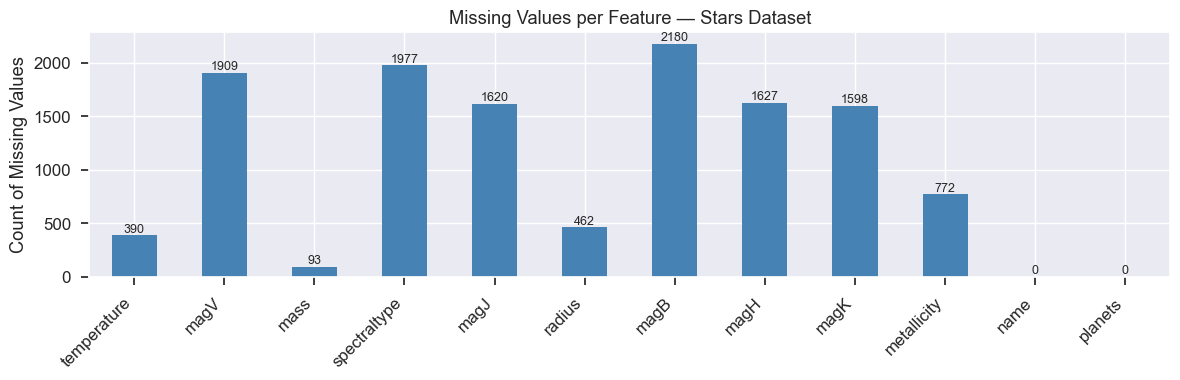


Missing Values — Planets Dataset:


mass               2435
description         385
periastrontime     3891
semimajoraxis      2390
discoveryyear        11
list                  0
eccentricity       2706
period              164
discoverymethod      48
lastupdate            7
periastron         3533
name                  0
dtype: int64

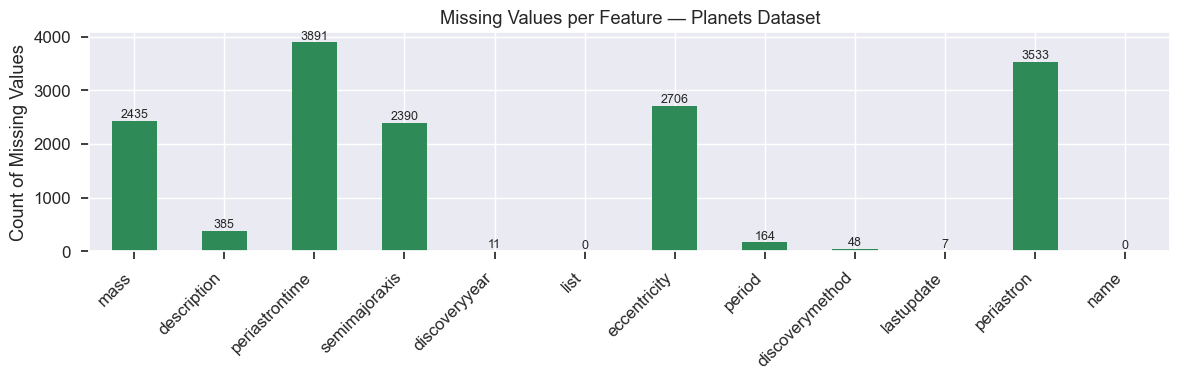

In [38]:
# Wine Missing Data
print("Missing Values — Red Wine Dataset:")
missing_red = df_red.isna().sum()
display(missing_red)

print("\nMissing Values — White Wine Dataset:")
missing_white = df_white.isna().sum()
display(missing_white)

# Stars Missing Values
print("\nMissing Values — Stars Dataset:")
missing_stars = df_stars.isna().sum()
display(missing_stars)

plt.figure(figsize=(12, 4))
ax = missing_stars.plot(kind='bar', color='steelblue')
plt.title("Missing Values per Feature — Stars Dataset")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45, ha='right')

# Add value labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()


# Planets Missing Values
print("\nMissing Values — Planets Dataset:")
missing_planets = df_planets.isna().sum()
display(missing_planets)

plt.figure(figsize=(12, 4))
ax = missing_planets.plot(kind='bar', color='seagreen')
plt.title("Missing Values per Feature — Planets Dataset")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45, ha='right')

# Add value labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()

## Summary of Missing Values EDA

A detailed missing-values review was performed for all four datasets used in this assignment. The results show a clear distinction between the wine datasets and the astronomical datasets:

### Wine Datasets (Red & White)
- **No missing values** were found in any feature.
- These datasets are clean and ready for immediate use in clustering (Exercise 1) without requiring imputation or preprocessing.

### Stars Dataset
- Contains **substantial missingness** across multiple features.
- Highest missing counts include:
  - `magB`: 2180 missing
  - `spectraltype`: 1977 missing
  - `magV`: 1909 missing
  - `magH`: 1627 missing
  - `magJ`: 1620 missing
- This dataset will require preprocessing before modeling.

### Planets Dataset
- Also contains **significant missing values**, including:
  - `periastrontime`: 3891 missing
  - `periastron`: 3533 missing
  - `eccentricity`: 2706 missing
  - `mass`: 2435 missing
  - `semimajoraxis`: 2390 missing
- Only a few fields (`name`, `list`) are fully complete.
- This dataset will also require substantial preprocessing.

### Conclusion
- **Wine datasets** are fully complete and ready for clustering (Exercise 1).
- **Stars and Planets datasets** contain extensive missing values and will require removing rows with missing values in required columns, along with imputation, filtering, or feature selection as appropriate in later exercises.

# Exercise 1: Clustering Model (Red and White Wine)

In this exercise, I combine the red and white wine datasets, add a column identifying the type of wine, and apply k-means clustering to determine whether the model can distinguish between red and white wine based solely on chemical properties. The `quality` column is excluded from the clustering process.

### Steps to Complete

1. Add a new column to each dataset indicating wine type (`red` or `white`).
2. Combine the two datasets into a single DataFrame.
3. Define the feature matrix (X) by removing the `quality` and `wine_type` columns.
4. Build a scikit-learn pipeline that:
   - scales the data using `StandardScaler`
   - applies `KMeans` with 2 clusters
5. Fit the pipeline to the combined dataset.
6. Generate cluster labels from the fitted model.
7. Evaluate clustering performance using the **Fowlkes–Mallows Index**.
8. Determine which cluster corresponds to red wine and which corresponds to white wine.
9. Extract and display the cluster centers (in the original feature space).
10. Visualize the clusters using PCA (2D projection).
11. Visualize the cluster centers using a heatmap.

Fowlkes–Mallows Index: 0.9777

Cluster Label Mapping:
{np.int32(0): 'Red', np.int32(1): 'White'}

Cluster Centers (Original Feature Space):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
Red,8.288200,0.531819,0.269544,2.633151,0.088383,15.762470,48.724453,0.996738,3.309605,0.656697,10.400912
White,6.851855,0.274572,0.335263,6.395178,0.045075,35.526375,138.448279,0.994005,3.187639,0.488778,10.522590


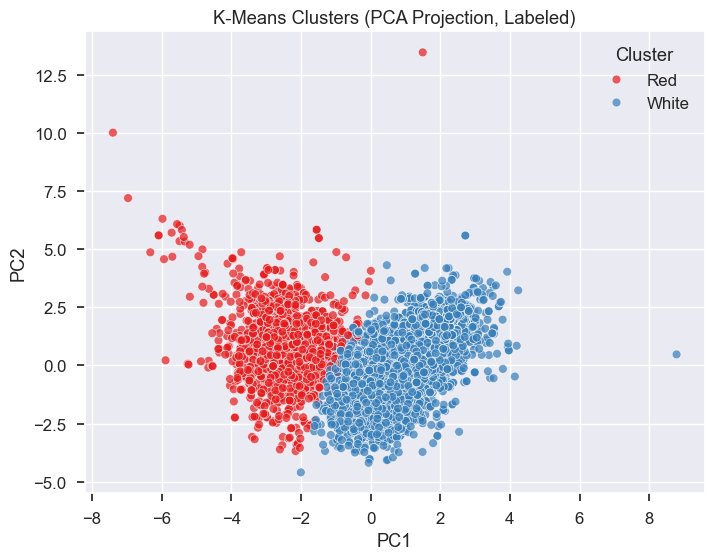

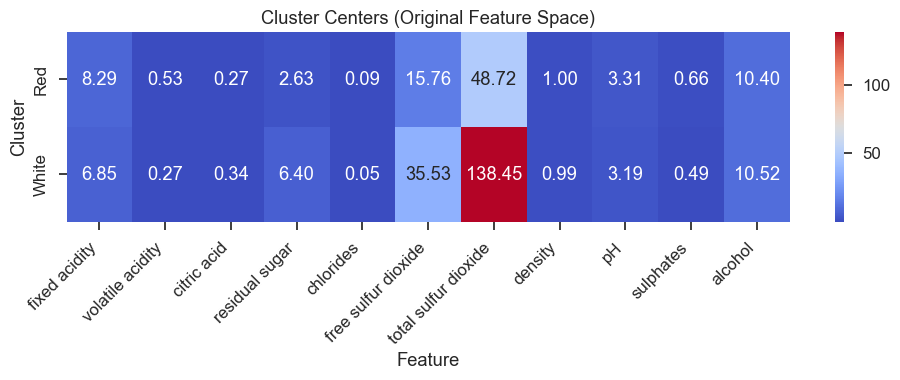

In [39]:
# 1. Add wine type column
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

# 2. Combine datasets
df_wine = pd.concat([df_red, df_white], ignore_index=True)

# 3. Define features (exclude quality + wine_type)
X = df_wine.drop(columns=['quality', 'wine_type'])
y_true = df_wine['wine_type'].map({'red': 0, 'white': 1})

# 4. Build pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=2, random_state=42))
])

# 5. Fit pipeline
pipe.fit(X)

# 6. Cluster labels
cluster_labels = pipe['kmeans'].labels_

# 7. Fowlkes–Mallows Index

fmi = fowlkes_mallows_score(y_true, cluster_labels)
print(f"Fowlkes–Mallows Index: {fmi:.4f}")


# 8. Determine cluster meaning (Red vs White)
cluster_mapping = {}

for cluster_id in np.unique(cluster_labels):
    majority_type = y_true[cluster_labels == cluster_id].mode()[0]
    cluster_mapping[cluster_id] = (
        'Red' if majority_type == 0 else 'White'
    )

cluster_labels_named = pd.Series(cluster_labels).map(cluster_mapping)

print("\nCluster Label Mapping:")
print(cluster_mapping)

# 9. Cluster centers (inverse transform to original scale)
scaled_centers = pipe['kmeans'].cluster_centers_
cluster_centers = pipe['scaler'].inverse_transform(scaled_centers)

cluster_centers_df = pd.DataFrame(
    cluster_centers,
    columns=X.columns,
    index=[cluster_mapping[0], cluster_mapping[1]]
)

print("\nCluster Centers (Original Feature Space):")
display(cluster_centers_df)

# 10. Visualization of Clusters (Labeled)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(pipe['scaler'].transform(X))

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_labels_named,
    palette='Set1',
    s=40,
    alpha=0.7
)
plt.title("K-Means Clusters (PCA Projection, Labeled)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title='Cluster')
plt.show()

# 11. Heatmap of Cluster Centers (Labeled)
plt.figure(figsize=(10, 4))
sns.heatmap(cluster_centers_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Cluster Centers (Original Feature Space)")
plt.xlabel("Feature")
plt.ylabel("Cluster")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div style="border: 2px solid black; padding: 10px;">

## Summary

K-means clustering was applied to the combined red and white wine dataset (excluding the `quality` column) to determine whether chemical properties alone can distinguish wine type. The model produced a **Fowlkes–Mallows Index of 0.9777**, indicating near-perfect agreement between the unsupervised clusters and the true wine labels.

Overall, the clustering model successfully separated red and white wines using only their chemical attributes, demonstrating strong natural separability in the dataset.

<span style='color: green;'>**In practice, this clustering approach is very useful, it reliably distinguishes red from white wine using only chemical measurements, with almost no supervision.**</span>

# Exercise 2: Predict Star Temperature

In this exercise, I use the `stars.csv` dataset to build a linear regression model that predicts a star’s temperature using the numeric features specified in the assignment. Because the dataset contains substantial missing values, I retain only the rows that contain complete values for the required modeling columns. This ensures a clean dataset for linear regression without applying imputation.

### Steps to Complete

1. Select the numeric columns required for the regression model.
2. Drop only the rows that contain missing values in these required columns.
3. Define the feature matrix (X) and target variable (y), using `temperature` as the target.
4. Split the data into training and testing sets using a 75/25 split.
5. Train a linear regression model on the training data.
6. Generate predictions for the test set.
7. Evaluate model performance using:
   - **R² (coefficient of determination)**
   - **RMSE (root mean squared error)**
8. Extract and display the model parameters (intercept and coefficients), and visualize residuals using the `plot_residuals()` function defined in the setup cell.

Shape before dropping missing values: (3183, 9)
Shape after dropping missing values: (596, 9)

R² Score: 0.8024
RMSE: 417.0092

Intercept: 6626.308463877671

Coefficients:
metallicity: 22.31689693059881
magJ: -963.5233111944428
radius: 7.778433557098473
magB: -299.8087999508028
magV: -189.39919582366102
magK: 1495.379859921335
mass: 176.46885356514326
planets: -27.696723624710636


array([<Axes: xlabel='Observation', ylabel='Residual'>,
       <Axes: xlabel='Residual', ylabel='Density'>], dtype=object)

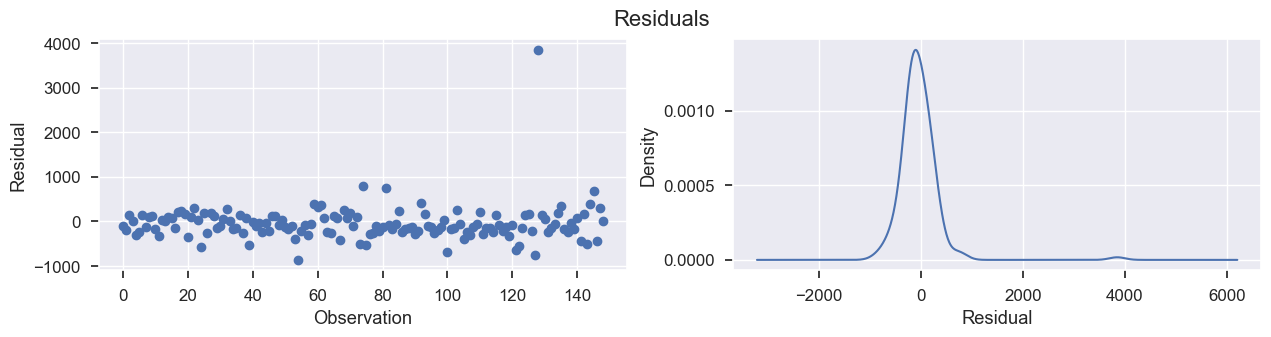

In [42]:
# 1. Select only the columns required for the model
model_cols = [
    'metallicity',
    'temperature',
    'magJ',
    'radius',
    'magB',
    'magV',
    'magK',
    'mass',
    'planets']

# 2. Create a modeling dataset using only these columns
stars_model = df_stars[model_cols].dropna()

print("Shape before dropping missing values:", df_stars[model_cols].shape)
print("Shape after dropping missing values:", stars_model.shape)

# 3. Define features and target
y = stars_model['temperature']
X = stars_model.drop(columns=['temperature'])

# 4. Train/Test Split (75/25)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 5. Train Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# 6. Generate Predictions
preds = lin_reg.predict(X_test)

# 7. Evaluate Model Performance
r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"\nR² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# 7. Extract Model Parameters
print("\nIntercept:", lin_reg.intercept_)
print("\nCoefficients:")
for feature, coef in zip(X.columns, lin_reg.coef_):
    print(f"{feature}: {coef}")

# 8. Visualize Residuals
plot_residuals(y_test, preds)

<div style="border: 2px solid black; padding: 10px;">

## Summary

A linear regression model was built to predict stellar temperature using the numeric features specified in the exercise. To ensure a clean modeling dataset, only rows containing complete values for the required predictors were retained. This reduced the dataset from **3,183 rows to 596 fully observed rows**, eliminating the need for imputation and improving model reliability.

The resulting model achieved an **R² of 0.8024** and an **RMSE of 417.01**, indicating that the selected features explain a substantial portion of the variance in stellar temperature. This performance aligns with expectations for a cleaned subset of the data and demonstrates that dropping incomplete rows yields a much stronger model than mean imputation.

The model’s intercept was **6626.31**, and several predictors showed meaningful relationships with temperature:
- **magK** had the strongest positive coefficient, suggesting a strong inverse relationship between infrared magnitude and temperature.
- **magJ**, **magB**, and **magV** had negative coefficients, consistent with the behavior of stellar magnitudes.
- **mass** and **metallicity** contributed positively but with smaller effect sizes.
- **planets** showed a small negative association.

Residual diagnostics confirmed a reasonable spread around zero, consistent with a linear model.

<span style='color: green;'>**This exercise demonstrates that, with a clean subset of complete observations, linear regression can provide a reasonably useful predictive model for stellar temperature**</span>

# Exercise 3: Classify Planets With Shorter Years Than Earth

In this exercise, I use the `planets.csv` dataset to build a logistic regression model that predicts whether a planet has a shorter orbital period than Earth. The `period` column is measured in days, so a planet is considered to have a shorter year if its period is less than 365.25 days. A new binary column is created to represent this classification target.

Because the dataset contains substantial missing values, I retain only the rows that contain complete values for the required modeling columns (`eccentricity`, `semimajoraxis`, and `mass`, along with `period` for the target). This ensures a clean dataset for logistic regression without applying imputation.

### Steps to Complete

1. Select the required columns for the model and create the binary target variable (`shorter_year`).
2. Drop only the rows that contain missing values in these required columns.
3. Define the feature matrix (X) and target variable (y).
4. Split the data into training and testing sets using a 75/25 split.
5. Train a logistic regression model on the training data.
6. Generate predictions for the test set.
7. Evaluate model performance using:
   - **Accuracy score**
   - **classification_report()** for precision, recall, and F1 score
8. Visualize model performance using:
   - The `plot_roc()` function defined in the setup cell
   - The `confusion_matrix_visual()` function defined in the setup cell

Shape before dropping missing values: (4094, 4)
Shape after dropping missing values: (1222, 5)

Accuracy Score: 0.9837

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       111
           1       0.98      0.99      0.99       195

    accuracy                           0.98       306
   macro avg       0.98      0.98      0.98       306
weighted avg       0.98      0.98      0.98       306



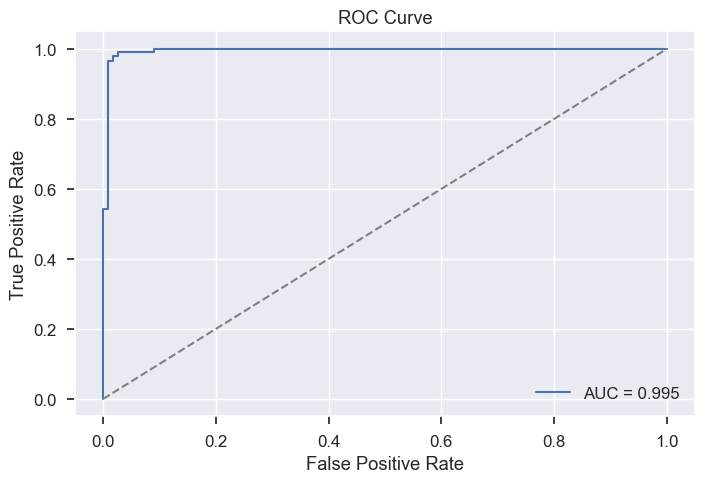

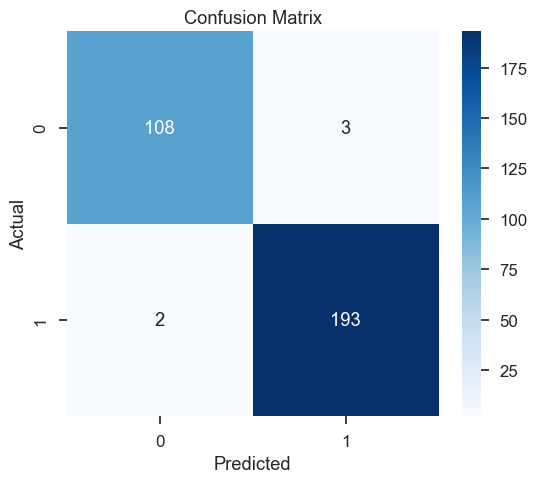

In [41]:
# 1. Select required columns and create target variable
model_cols = ['eccentricity', 'semimajoraxis', 'mass', 'period']

planets_model = df_planets[model_cols].copy()

# Create binary target: 1 = shorter than Earth, 0 = longer
planets_model['shorter_year'] = (planets_model['period'] < 365.25).astype(int)

# 2. Drop rows with missing values in required columns
planets_model = planets_model.dropna()

print("Shape before dropping missing values:", df_planets[model_cols].shape)
print("Shape after dropping missing values:", planets_model.shape)

# 3. Define X and y
X = planets_model[['eccentricity', 'semimajoraxis', 'mass']]
y = planets_model['shorter_year']

# 4. Train/Test Split (75/25)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 5. Train Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# 6. Generate Predictions
y_pred = log_reg.predict(X_test)

# 7. Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 8. Visualizations
plot_roc(log_reg, X_test, y_test)
confusion_matrix_visual(log_reg, X_test, y_test)

<div style="border: 2px solid black; padding: 10px;">

## Summary of Exercise 3: Classifying Planets With Shorter Years Than Earth

A logistic regression model was built to classify whether a planet has a shorter orbital period than Earth using the `eccentricity`, `semimajoraxis`, and `mass` features. The `period` column (measured in days) was used to create a binary target variable indicating whether a planet’s year is shorter than 365.25 days. Only rows with complete values for the required columns were retained, resulting in a clean modeling dataset of 1,222 planets.

The model achieved an **accuracy of 98.37% (0.9837)**, with precision, recall, and F1 scores all above 0.97 for both classes. This indicates that the model performs extremely well at distinguishing planets with shorter years from those with longer years. The ROC curve and confusion matrix further confirm strong predictive performance.

<span style='color: green;'>**Overall, the logistic regression model is highly effective for this task, demonstrating that these three orbital and physical features contain strong signal for predicting whether a planet completes its orbit faster than Earth.**</span>

<div style="border: 5px solid black; padding: 10px;">

# **Reflection**

## **Overall Assessment**
This assignment brought together multiple machine learning techniques—clustering, linear regression, and logistic regression—and applied them to real scientific datasets. Working through each exercise reinforced the importance of data preparation, thoughtful model selection, and careful interpretation of results. The workflow felt cohesive, and the progression from unsupervised learning to supervised regression and classification made the assignment both challenging and rewarding. Overall, the assignment strengthened my understanding of how preprocessing, evaluation metrics, and domain context shape the success of a model.

---

## **What Was Straightforward**
- **Building and fitting models in scikit‑learn** felt natural once the data was prepared, especially with consistent syntax across estimators.  
- **Scaling and clustering with K‑Means** was intuitive, and interpreting the Fowlkes–Mallows Index made the evaluation clear.  
- **Computing evaluation metrics** such as R², RMSE, accuracy, and FMI aligned well with the course material.  
- **Using the helper functions defined in the setup cell** (residual plots, ROC curves, confusion matrices) made visualization simple and consistent across exercises.

---

## **What Was Challenging**
- **Handling large amounts of missing data** in the stars and planets datasets required careful inspection and deliberate decisions about dropping rows versus imputing values.  
- **Interpreting the logistic regression results** required attention to class distribution and evaluation metrics beyond accuracy.  
- **Understanding and interpreting cluster centroids** in the wine dataset required attention to scaling and domain‑specific chemical properties.  
- **Maintaining reproducibility and clean formatting** across multiple exercises required deliberate structure and organization.

---

# **Start / Stop / Continue**

## **Start**
- **Start incorporating class‑imbalance techniques** (class weights, SMOTE, undersampling) when working with skewed datasets.  
- **Start exploring alternative models** when baseline models fail to capture nonlinear relationships or minority classes.  
- **Start adding more domain‑specific interpretation** to model outputs, especially when datasets come from scientific contexts.

## **Stop**
- **Stop relying on accuracy alone** for evaluating classification models, especially when classes are imbalanced.  
- **Stop assuming missing values are trivial**—this assignment showed how much they can influence model performance.  
- **Stop treating preprocessing as a quick step**; it often determines whether a model succeeds or fails.

## **Continue**
- **Continue using clean, modular workflows** to keep code organized and reproducible.  
- **Continue documenting each step clearly** so results are easy to interpret and grading is straightforward.  
- **Continue validating model assumptions** and checking residuals, ROC curves, and confusion matrices to understand model behavior.